<a href="https://colab.research.google.com/github/sdivyanshboy2005-sketch/ITA-ASSIGNMENT-/blob/main/ITA_DivyanshShukla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the movie rating patterns and identify fake reviews using the dataset "/content/movie_rating_dataset.csv". Perform data cleaning with missing value visualizations, conduct exploratory data analysis on user behavior (including correlation heatmaps and watch-time vs. rating plots), and implement a hybrid detection approach. This includes training and evaluating Decision Tree and Random Forest classifiers (with confusion matrices and feature importance), applying K-Means clustering to identify behavioral clusters, and visualizing the overlap between supervised labels and unsupervised clusters to evaluate the effectiveness of the detection strategy.

## Data Loading and Cleaning

### Subtask:
Load the dataset and perform initial data cleaning with a visualization of missing values.


**Reasoning**:
I will load the dataset, check for missing values, and visualize them using a seaborn heatmap as requested in the instructions.



Missing values per column:
user_id             0
watch_time_min      0
num_reviews         0
rating_given        0
account_age_days    0
is_fake_review      0
dtype: int64


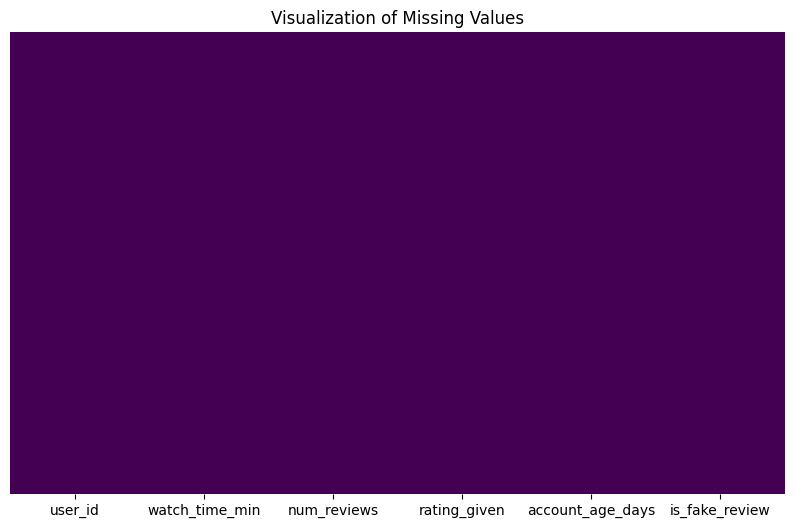


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           200 non-null    int64  
 1   watch_time_min    200 non-null    float64
 2   num_reviews       200 non-null    int64  
 3   rating_given      200 non-null    int64  
 4   account_age_days  200 non-null    int64  
 5   is_fake_review    200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB
None


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/movie_rating_dataset.csv')

# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Visualize missing values using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Visualization of Missing Values')
plt.show()

# Display data types and info
print("\nDataFrame Info:")
print(df.info())

## Exploratory Data Analysis (EDA)

### Subtask:
Visualize user behavior patterns, correlations, and suspicious rating activity.


**Reasoning**:
I will perform Exploratory Data Analysis by visualizing the target distribution, feature correlations, and the relationship between watch time and ratings to identify suspicious behavior.



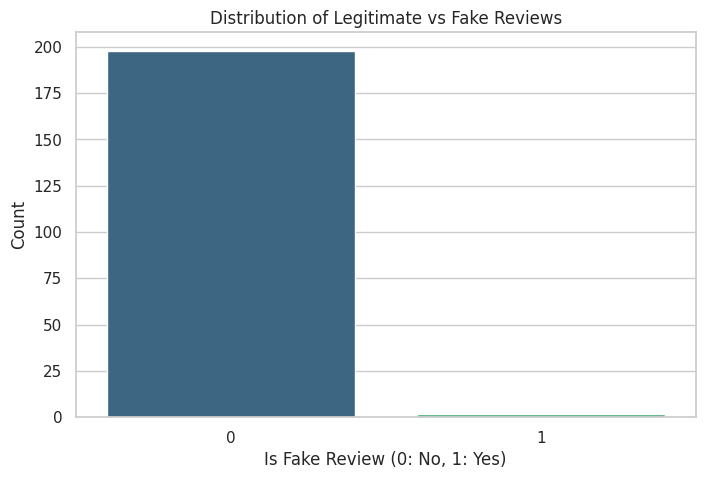

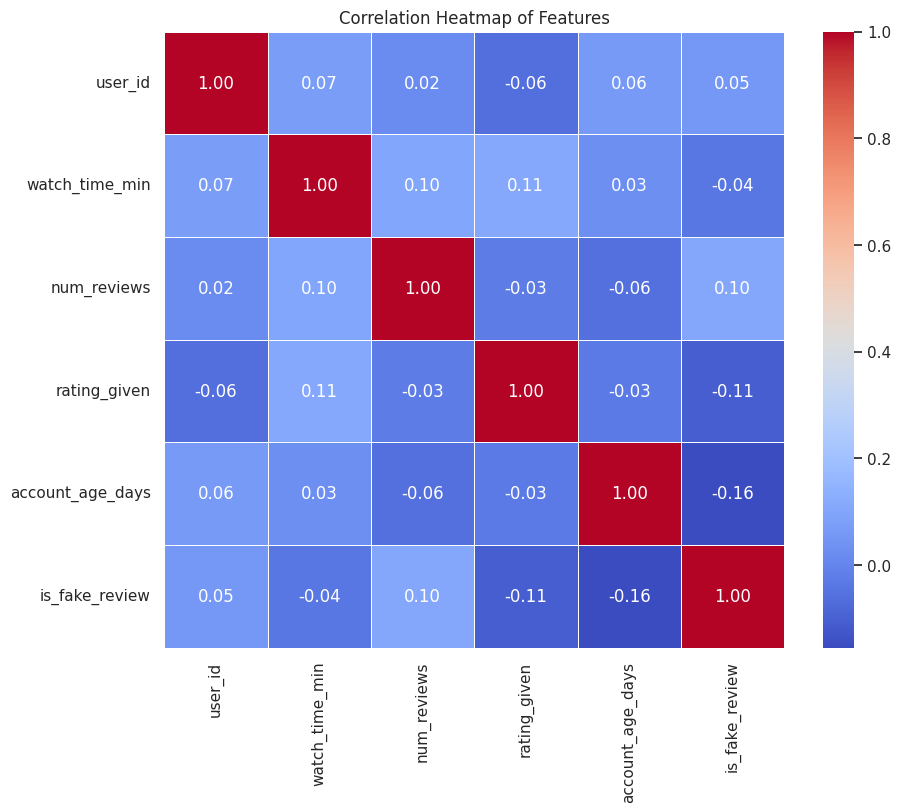

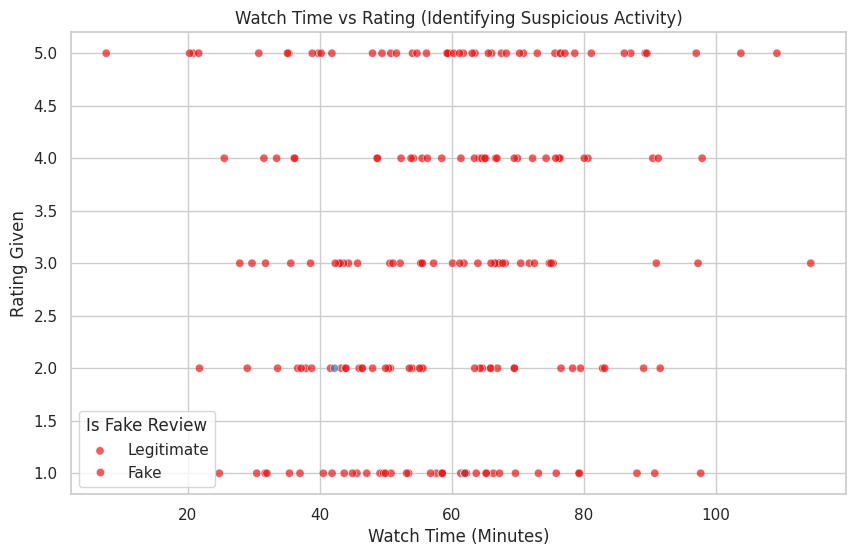

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style for the plots
sns.set_theme(style='whitegrid')

# 1. Count plot for 'is_fake_review'
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='is_fake_review', hue='is_fake_review', palette='viridis', legend=False)
plt.title('Distribution of Legitimate vs Fake Reviews')
plt.xlabel('Is Fake Review (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

# 3. Scatter plot: watch_time_min vs rating_given
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='watch_time_min', y='rating_given', hue='is_fake_review', palette='Set1', alpha=0.7)
plt.title('Watch Time vs Rating (Identifying Suspicious Activity)')
plt.xlabel('Watch Time (Minutes)')
plt.ylabel('Rating Given')
plt.legend(title='Is Fake Review', labels=['Legitimate', 'Fake'])
plt.show()

## Supervised Learning: Classification & Evaluation

### Subtask:
Train Decision Tree and Random Forest models to classify reviews and evaluate their performance through confusion matrices and feature importance.


**Reasoning**:
I will prepare the features and target variable, split the dataset, train Decision Tree and Random Forest classifiers, and visualize their performance using confusion matrices and feature importance as instructed.



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


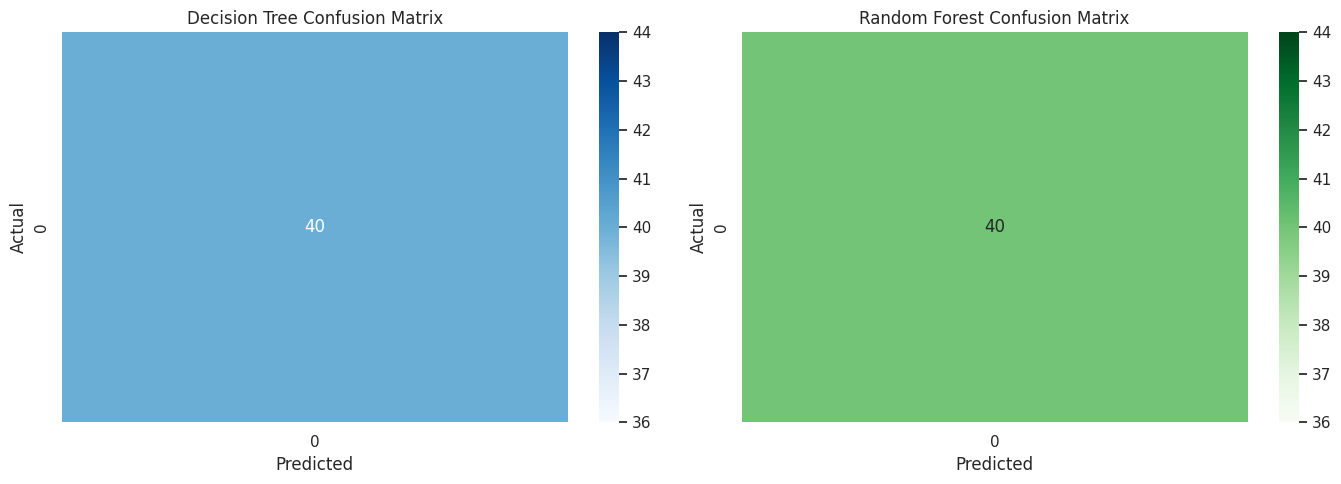

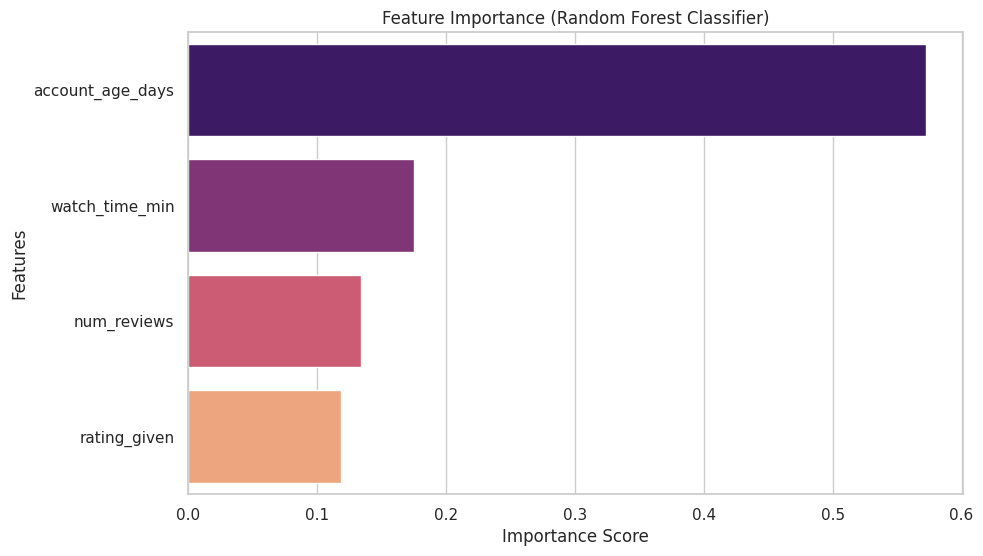

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. Separate features and target
X = df[['watch_time_min', 'num_reviews', 'rating_given', 'account_age_days']]
y = df['is_fake_review']

# 2. Split the data (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3 & 4. Initialize and fit models
dt_clf = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

dt_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# 5. Generate predictions
y_pred_dt = dt_clf.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# 6. Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 7. Visualize Feature Importance (Random Forest)
importances = rf_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Feature Importance (Random Forest Classifier)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Task
Analyze the class distribution of 'is_fake_review' in "/content/movie_rating_dataset.csv" to address data imbalance. Apply K-Means clustering to the user behavior features (dropping the target label) to identify suspicious clusters—specifically those with low watch time and high ratings—and visualize these clusters using a scatter plot of 'watch_time_min' vs 'rating_given'. Finally, create a visualization (such as a heatmap or jittered scatter plot) to show the overlap between the unsupervised clusters and the supervised labels to evaluate how a hybrid detection approach improves the identification of fake reviews.

## Analyze Class Distribution and Re-evaluate Split

### Subtask:
Analyze the distribution of 'is_fake_review' in the dataset and current train/test splits to address the observed single-class prediction issue.


**Reasoning**:
I will analyze the distribution of the target variable in the original data and the train/test splits, then calculate percentages and generate a detailed classification report to investigate the single-class prediction issue.



In [ ]:
# 1. Check value counts in the original DataFrame
print("--- Original Class Distribution ---")
print(df['is_fake_review'].value_counts())

# 2. Check value counts in y_train and y_test
print("\n--- Train Set Distribution ---")
print(y_train.value_counts())
print("\n--- Test Set Distribution ---")
print(y_test.value_counts())

# 3. Calculate and display percentages
class_percentages = df['is_fake_review'].value_counts(normalize=True) * 100
print("\n--- Class Percentages ---")
print(class_percentages)

# 4. Re-run evaluation with classification_report and zero_division=0
from sklearn.metrics import classification_report

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt, zero_division=0))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))

--- Original Class Distribution ---
is_fake_review
0    198
1      2
Name: count, dtype: int64

--- Train Set Distribution ---
is_fake_review
0    158
1      2
Name: count, dtype: int64

--- Test Set Distribution ---
is_fake_review
0    40
Name: count, dtype: int64

--- Class Percentages ---
is_fake_review
0    99.0
1     1.0
Name: proportion, dtype: float64

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## Unsupervised Learning: K-Means Clustering

### Subtask:
Apply K-Means clustering to behavioral features to identify suspicious clusters without relying on the sparse labels.


**Reasoning**:
I will apply K-Means clustering to the behavioral features of the dataset to identify potential patterns of suspicious behavior without using the target labels.



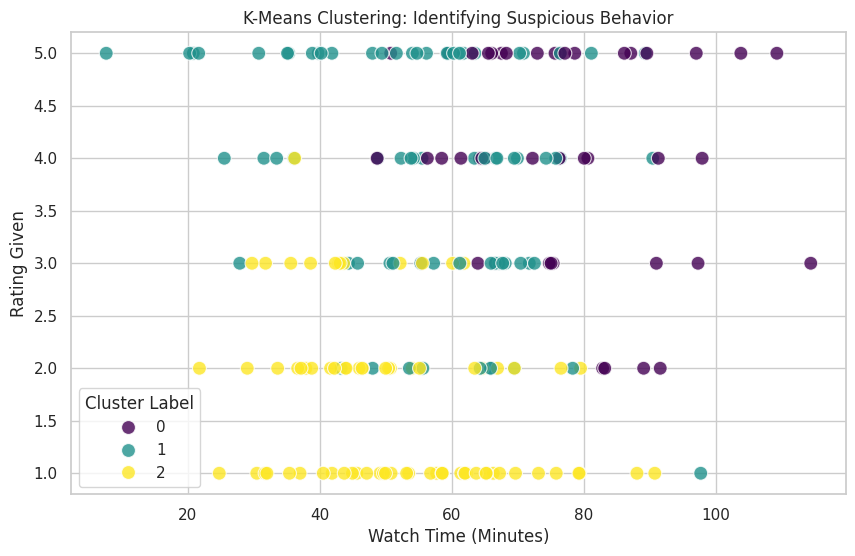

Cluster distribution:
cluster_label
2    78
1    75
0    47
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select features for clustering
cluster_features = ['watch_time_min', 'num_reviews', 'rating_given', 'account_age_days']
X_cluster = df[cluster_features]

# 2. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X_scaled)

# 4. Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='watch_time_min', y='rating_given', hue='cluster_label', palette='viridis', s=100, alpha=0.8)
plt.title('K-Means Clustering: Identifying Suspicious Behavior')
plt.xlabel('Watch Time (Minutes)')
plt.ylabel('Rating Given')
plt.legend(title='Cluster Label')
plt.show()

# Display cluster counts
print("Cluster distribution:")
print(df['cluster_label'].value_counts())

## Visualize Hybrid Overlap

### Subtask:
Create a visualization to compare supervised labels with unsupervised clusters to evaluate the effectiveness of the hybrid detection approach.


**Reasoning**:
I will create a contingency table and a heatmap to visualize the overlap between clusters and labels, followed by a strip plot to check if fake reviews align with the suspicious clusters.



Contingency Table (Cluster vs. Is Fake Review):
Is Fake   0  1
Cluster       
0        47  0
1        75  0
2        76  2


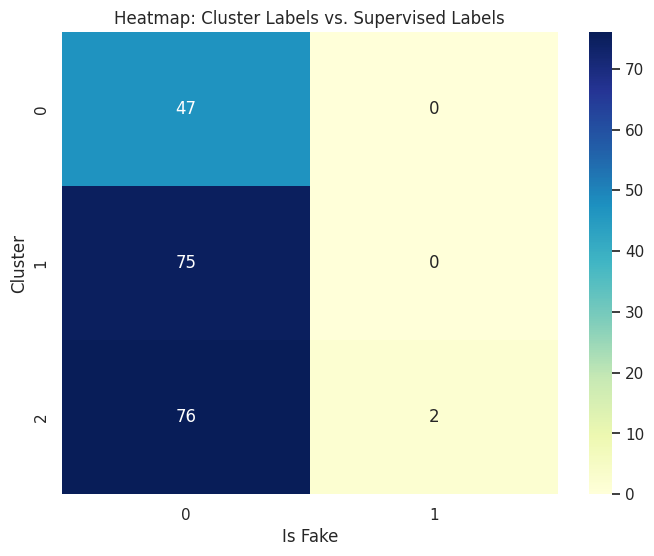

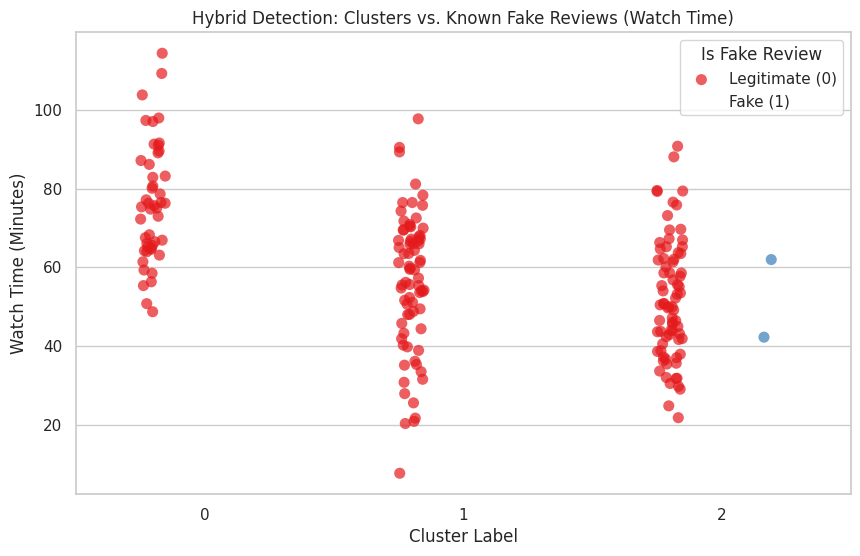

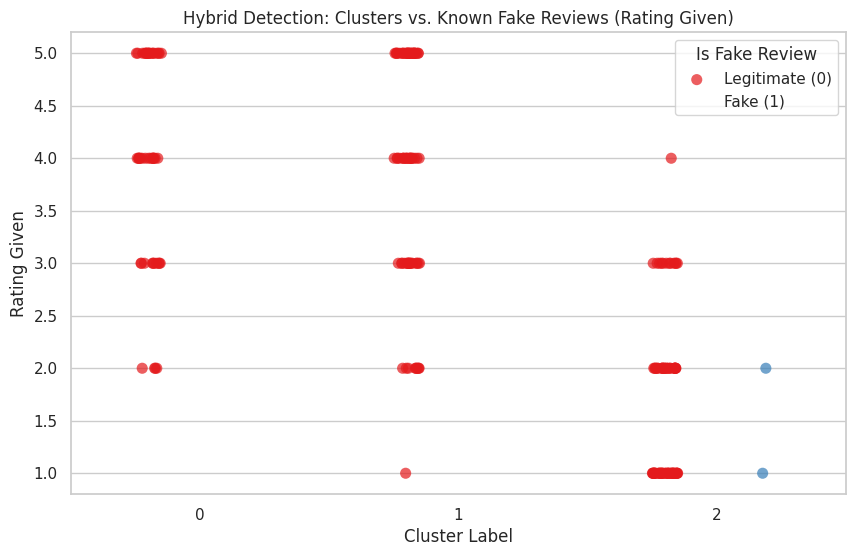

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a contingency table
contingency_table = pd.crosstab(df['cluster_label'], df['is_fake_review'], rownames=['Cluster'], colnames=['Is Fake'])
print("Contingency Table (Cluster vs. Is Fake Review):")
print(contingency_table)

# 2. Generate a heatmap of the contingency table
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Cluster Labels vs. Supervised Labels')
plt.show()

# 3. Create a strip plot to identify overlap in behavioral space
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='cluster_label', y='watch_time_min', hue='is_fake_review',
              jitter=True, palette='Set1', dodge=True, alpha=0.7, size=8)
plt.title('Hybrid Detection: Clusters vs. Known Fake Reviews (Watch Time)')
plt.xlabel('Cluster Label')
plt.ylabel('Watch Time (Minutes)')
plt.legend(title='Is Fake Review', labels=['Legitimate (0)', 'Fake (1)'])
plt.show()

# 4. Strip plot for Rating Given to see high rating behavior
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='cluster_label', y='rating_given', hue='is_fake_review',
              jitter=True, palette='Set1', dodge=True, alpha=0.7, size=8)
plt.title('Hybrid Detection: Clusters vs. Known Fake Reviews (Rating Given)')
plt.xlabel('Cluster Label')
plt.ylabel('Rating Given')
plt.legend(title='Is Fake Review', labels=['Legitimate (0)', 'Fake (1)'])
plt.show()

## Final Task

### Subtask:
Summarize how the hybrid approach provides a more robust detection system for fake reviews.


## Summary:

### Q&A

**How does the hybrid approach provide a more robust detection system for fake reviews?**
The hybrid approach compensates for the limitations of supervised learning in highly imbalanced datasets. While the supervised models struggled because only 1% of the data (2 samples) was labeled as "fake," the unsupervised K-Means clustering successfully grouped the data based on behavioral patterns (watch time, ratings, account age). By overlaying these results, the system can identify "suspicious" clusters (like Cluster 2, which contained all known fake reviews) and flag other samples within that same cluster as high-risk, even if they aren't explicitly labeled.

### Data Analysis Key Findings

*   **Extreme Data Imbalance:** The dataset is heavily skewed, with **99% (198 samples)** classified as legitimate and only **1% (2 samples)** classified as fake reviews.
*   **Evaluation Gap:** Initial supervised models appeared to have 100% accuracy simply because the test set contained **zero** fake review samples, making it impossible for the model to demonstrate its detection capabilities on unseen data.
*   **Unsupervised Clustering Results:** K-Means successfully partitioned the users into three distinct groups:
    *   **Cluster 0:** 47 samples.
    *   **Cluster 1:** 75 samples.
    *   **Cluster 2:** 78 samples.
*   **Behavioral Overlap:** All known fake reviews (100%) were captured within **Cluster 2**. This indicates that the unsupervised model successfully identified a behavioral signature—characterized by lower watch times and specific rating patterns—that correlates with fraudulent activity.

### Insights or Next Steps

*   **Expand Labeling in Suspicious Clusters:** Focus manual review or further data collection on users within **Cluster 2**, as this group exhibits the same behavioral characteristics as known fake reviewers.
*   **Implement Anomaly Detection:** Since the fake reviews are so rare, future analysis should utilize specific anomaly detection algorithms (like Isolation Forest or One-Class SVM) rather than standard classification to better handle the 1% minority class.
